<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict, defaultdict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils
import scipy.sparse as sp
import squidpy as sq

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWar

# Spatial

In [3]:
dataset_name = "visium_human_mouse"  # options: visium_human_mouse - https://www.10xgenomics.com/datasets/visium-hd-three-prime-human-mouse-xenograft-fresh-frozen
technology = "visium_hd"  # options: visium_hd, merfish
resolution = "008um"  # options: 002um, 008um, 016um, etc
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [ ]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "visium_human_mouse":
    binned_outputs_url = "https://cf.10xgenomics.com/samples/spatial-exp/4.0.1/Visium_HD_3prime_Human_Mouse_Xenograft/Visium_HD_3prime_Human_Mouse_Xenograft_binned_outputs.tar.gz",
    expected_cells = 250_000
    leiden_resolution = 1.0
elif dataset_name == "merfish":
    binned_outputs_url = "xxxxx"
    expected_cells = None
    leiden_resolution = 1.0
else:
    raise ValueError(f"Unknown dataset_name: {dataset_name}")

if technology == "visium_hd":
    binned_outputs_dir = f"{data_dir}/binned_outputs"
    if not os.path.exists(binned_outputs_dir):
        !wget -O {binned_outputs_dir}.tar.gz {binned_outputs_url}
        !tar -xvzf {binned_outputs_dir}.tar.gz -C {data_dir}
    matrix_dir_raw = os.path.join(binned_outputs_dir, f"square_{resolution}")
elif technology == "merfish":
    # matrix_dir_raw = os.path.join(binned_outputs_dir, f"square_{resolution}")
    pass
else:
    raise ValueError(f"Unknown technology: {technology}")

adata_path_cellsweep = os.path.join(data_dir, "adata_cellsweep.h5ad")
cellsweep_log_file = os.path.join(data_dir, "cellsweep.log")

## Knee plot - use this output to estimate umi_cutoff

In [5]:
if technology == "visium_hd":
    # adata_raw = sq.read.visium(
    #     path=matrix_dir_raw,
    #     counts_file=os.path.join(matrix_dir_raw, "filtered_feature_bc_matrix.h5")
    # )

    adata_raw = cs_utils.load_adata(os.path.join(matrix_dir_raw, "filtered_feature_bc_matrix.h5"))
    adata_raw.var_names_make_unique()

    spatial_df = pd.read_parquet(os.path.join(matrix_dir_raw, "spatial", "tissue_positions.parquet"))
    adata_raw.obs = adata_raw.obs.merge(spatial_df.set_index("barcode"), left_index=True, right_index=True, how="left")

    adata_raw.obsm["spatial"] = adata_raw.obs[["pxl_col_in_fullres", "pxl_row_in_fullres"]].values
elif technology == "merfish":
    pass
else:
    raise ValueError(f"Unknown technology: {technology}")

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
adata_raw

AnnData object with n_obs × n_vars = 515980 × 72302
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

UMI cutoff for expected cells (250000): 32.00


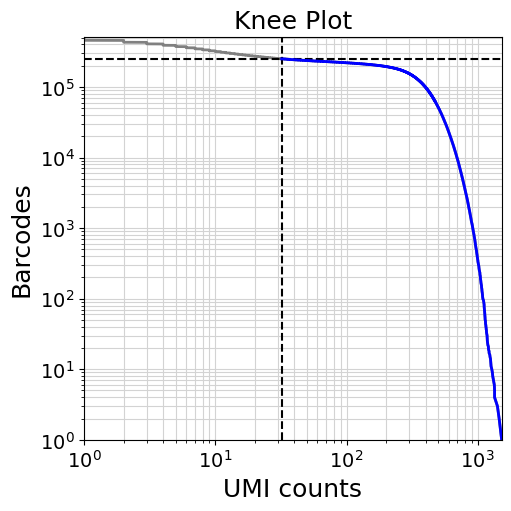

In [7]:
expected_cells = 250_000
umi_cutoff = cs_utils.knee_plot(adata_raw, transpose=True, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [8]:
# umi_cutoff = 0  #!!! optionally update from knee plot
adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

## cellsweep

In [ ]:
if not os.path.exists(adata_path_cellsweep) or overwrite:
    adata = adata_raw.copy()
    if "celltype" not in adata_raw.obs.columns:
        adata_processed_tmp = adata_raw[~adata_raw.obs["is_empty"]].copy()
        adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
        adata_raw.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata_raw.obs.index).astype(str).replace("nan", "empty").astype("category")
    adata_cellsweep = denoise_count_matrix(adata_raw, init_alpha=0.9, beta=0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
else:
    adata_cellsweep = cs_utils.load_adata(adata_path_cellsweep, verbose=verbose)

adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
adata_cellsweep.var_names_make_unique()

16:15:48 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/output/visium_human_mouse/adata_cellsweep.h5ad'


## Analysis

### Raw vs cellsweep knee plot, scatterplots

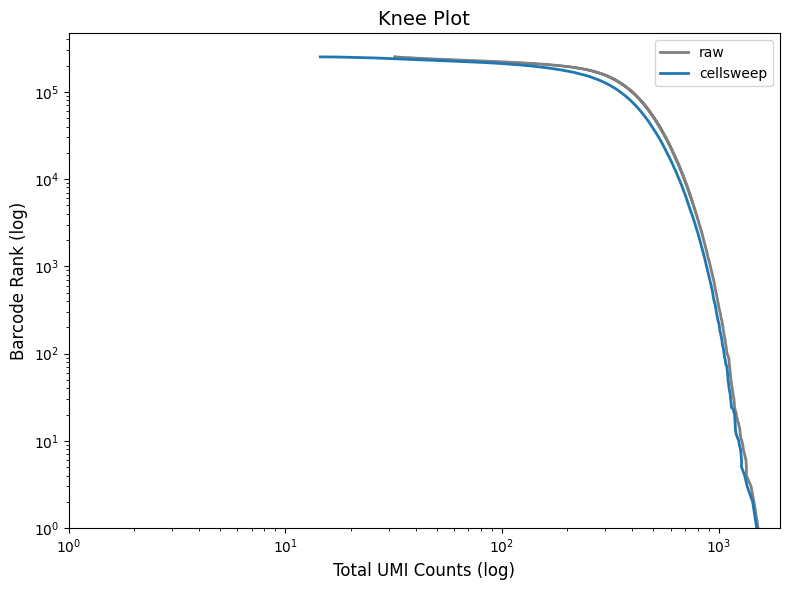

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


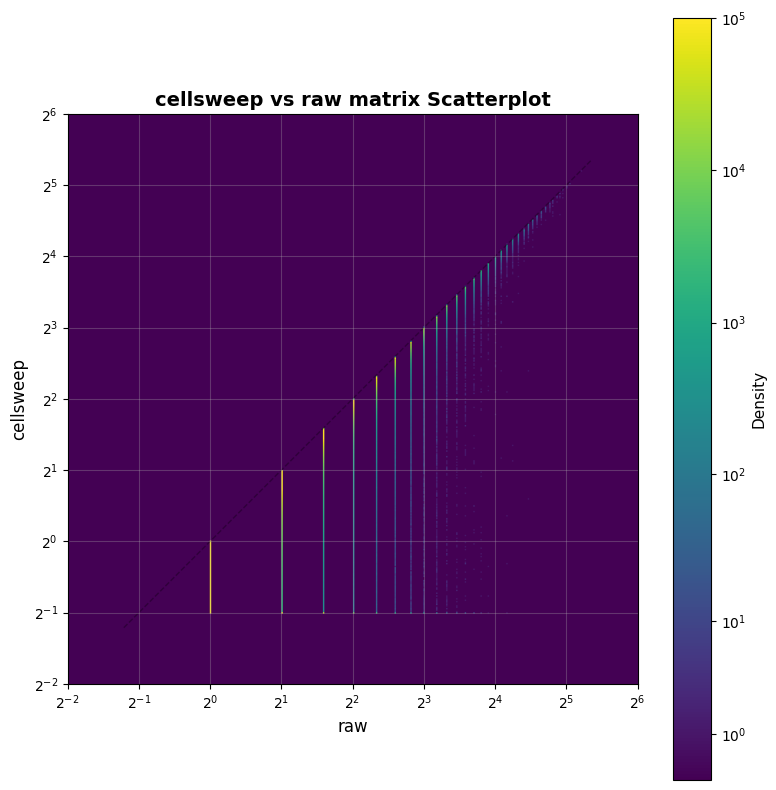

Creating scatterplot...
Calculating scatterplot...


: 

: 

In [10]:
cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=["raw", "cellsweep"], title="Knee Plot", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, "cellsweep_knee_plot.png"))

cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, "matrix_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, "cell_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, "gene_expression_scatterplot.png"), show=True)

## Spatial localization of alpha_hat

In [ ]:
adata_raw

AnnData object with n_obs × n_vars = 515980 × 72302
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'empty_counts', 'ambient', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike'
    layers: 'raw'

In [ ]:
adata_cellsweep

AnnData object with n_obs × n_vars = 515980 × 72302
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'empty_counts', 'ambient', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike'
    layers: 'raw'

In [ ]:
sq.gr.spatial_neighbors(
    adata_cellsweep,
    coord_type="generic",   # Visium HD
    n_neighs=6              # hex-like neighborhood
)

KeyError: 'Spatial basis `spatial` not found in `adata.obsm`.'

In [ ]:
sq.gr.spatial_autocorr(
    adata_cellsweep,
    mode="moran",
    genes=["alpha_hat"]
)

In [ ]:
# sc.pl.spatial(
#     adata_cellsweep,
#     color="alpha_hat",
#     size=1.0,
#     cmap="viridis"
# )

sq.gr.spatial_smooth(
    adata_cellsweep,
    keys=["alpha_hat"],
    n_neighs=6
)

sc.pl.spatial(
    adata_cellsweep,
    color="alpha_hat_smooth",
    size=1.0,
    cmap="viridis"
)
